## Diego Yasir Marin Medina 
- 23096254

In [41]:
# importar las ibrerias
import pandas as pd
import matplotlib.pyplot as plt
# cargar el data set
data = pd.read_csv('candy.csv')

In [42]:
# comporbar si el dataset fue cargado correctamente completo
data

,id,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,0,100 Grand,Yes,No,Yes,No,No,Yes,No,Yes,No,0.732,0.860,66.971725
1,1,3 Musketeers,Yes,No,No,No,Yes,No,No,Yes,No,0.604,0.511,67.602936
2,2,Air Heads,No,Yes,No,No,No,No,No,No,No,0.906,0.511,52.341465
3,3,Almond Joy,Yes,No,No,Yes,No,No,No,Yes,No,0.465,0.767,50.347546
4,4,Baby Ruth,Yes,No,Yes,Yes,Yes,No,No,Yes,No,0.604,0.767,56.914547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,78,Twizzlers,No,Yes,No,No,No,No,No,No,No,0.220,0.116,45.466282
79,79,Warheads,No,Yes,No,No,No,No,Yes,No,No,0.093,0.116,39.011898
80,80,Welch's Fruit Snacks,No,Yes,No,No,No,No,No,No,Yes,0.313,0.313,44.375519
81,81,Werther's Original Caramel,No,No,Yes,No,No,No,Yes,No,No,0.186,0.267,41.904308


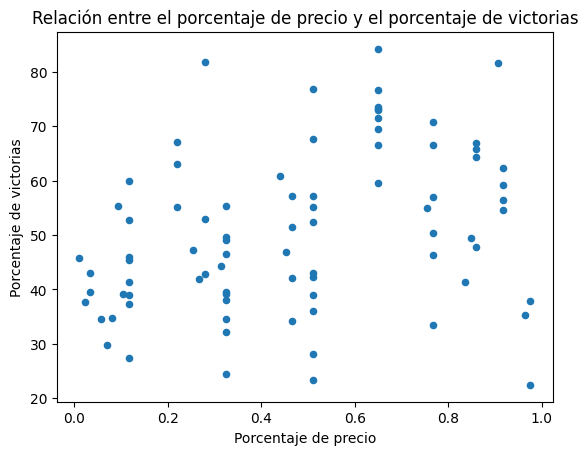

In [43]:
# obtener el modelo representativo de graficos de los datos (precio y vistorias que tuvieron los dulces favoritos)
data.plot(x='pricepercent', y='winpercent', kind='scatter')
plt.title('Relación entre el porcentaje de precio y el porcentaje de victorias')
plt.xlabel('Porcentaje de precio')
plt.ylabel('Porcentaje de victorias')
plt.show()

In [44]:
# buscar el coeficiente de correlacion entre el porcentaje de precio y el porcentaje de victorias
correlation = data['pricepercent'].corr(data['winpercent'])
print(f'El coeficiente de correlación entre el porcentaje de precio y el porcentaje de victorias es: {correlation}')


El coeficiente de correlación entre el porcentaje de precio y el porcentaje de victorias es: 0.3338611144196428


In [45]:
# buscar el coeficiente de determinación entre el porcentaje de precio y el porcentaje de victorias
determination = correlation ** 2
print(f'El coeficiente de determinación entre el porcentaje de precio y el porcentaje de victorias es: {determination}')

El coeficiente de determinación entre el porcentaje de precio y el porcentaje de victorias es: 0.1114632437215258


In [46]:
# ¿qué porcentaje de victorias se puede esperar para un producto con porcentaje de precio del 0.95%?
predicted_winpercent = correlation * 0.95
print(f'El porcentaje de victorias predicho para un producto con un porcentaje de precio del 0.95% es: {predicted_winpercent}')


El porcentaje de victorias predicho para un producto con un porcentaje de precio del 0.95% es: 0.3171680586986606


## Analisis y Recomendacion Final

Este analisis examina la relacion entre el porcentaje de precio pricepercent y el porcentaje de victorias winpercent de los dulces en una encuesta de preferencias.

### Interpretacion
Los calculos muestran:
- Coeficiente de correlacion: Mide que tan fuerte es la relacion entre precio y victorias
- Coeficiente de determinacion: Indica que porcentaje de las victorias puede explicarse unicamente por el precio

### Recomendación para Productores
Para lanzar un nuevo dulce exitoso, los productores deben considerar:

1. Estrategia de precio: Si la correlacion es debil, significa que el precio no es el factor dominante en la preferencia. El sabor, calidad y posicionamiento de marca son más importantes.

2. Punto de equilibrio: Analizar donde caen los dulces mas populares en terminos de precio y victorias permite posicionar un nuevo producto en una zona competitiva.

3. Validacion de modelo: La prediccion del 0.95% de precio nos ayuda a estimar el desempeno esperado, pero debe complementarse con otros factores del mercado.

### Conclusion
El analisis precio y victorias proporciona algo inicial, pero una estrategia completa requiere evaluar tambien caracteristicas del producto.

## Punto 2 de la parte practica

In [47]:
# leer un nuevo .csv par aun nuevo analisis
data2 = pd.read_csv('bank.csv')
data2

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [48]:
# evaluar normalidad en la columna age (Shapiro-Wilk test y Kolmogorov-Smirnov test)
from scipy import stats

# Test de Shapiro-Wilk
shapiro_stat, shapiro_p = stats.shapiro(data2['age'])
print("SHAPIRO-WILK")
print(f"Estadistico: {shapiro_stat:.6f}")
print(f"P-value: {shapiro_p:.6f}")
print()
if shapiro_p > 0.05:
    print("Resultado: La columna 'age' parece NORMAL ")
else:
    print("Resultado: La columna 'age' no parece NORMAL ")
print()

# Test de Kolmogorov-Smirnov
ks_stat, ks_p = stats.kstest(data2['age'], 'norm', args=(data2['age'].mean(), data2['age'].std()))
print("KOLMOGOROV-SMIRNOV")
print(f"Estadistico: {ks_stat:.6f}")
print(f"P-value: {ks_p:.6f}")
print()
if ks_p > 0.05:
    print("Resultado: La columna 'age' parece NORMAL ")
else:
    print("Resultado: La columna 'age' no parece NORMAL ")
print()


SHAPIRO-WILK
Estadistico: 0.947220
P-value: 0.000000

Resultado: La columna 'age' no parece NORMAL 

KOLMOGOROV-SMIRNOV
Estadistico: 0.102238
P-value: 0.000000

Resultado: La columna 'age' no parece NORMAL 



C:\Users\yasir\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 11162.
  res = hypotest_fun_out(*samples, **kwds)


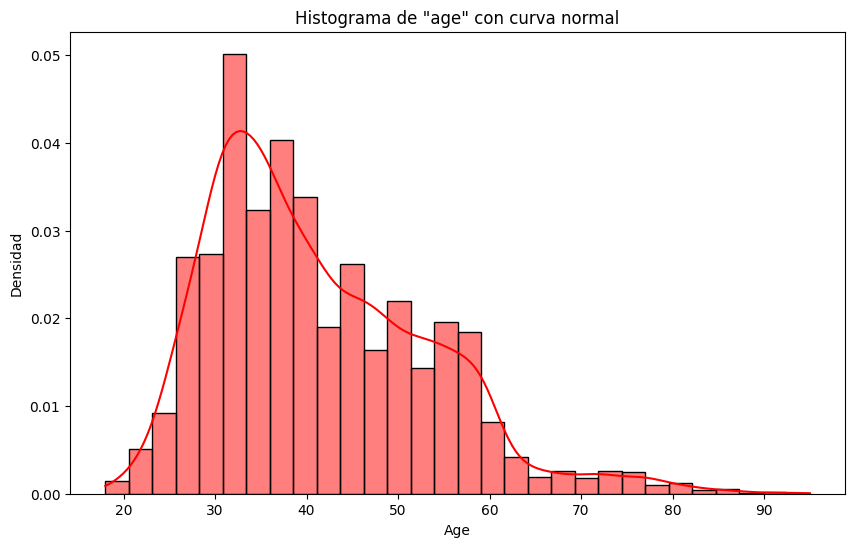

In [49]:
# complementar con un histogram con curva normal
import seaborn as sys

plt.figure(figsize=(10, 6))
sys.histplot(data2['age'], kde=True, stat="density", bins=30, color='red')
plt.title('Histograma de "age" con curva normal')
plt.xlabel('Age')
plt.ylabel('Densidad')
plt.show()

In [50]:
# realizar la media, mediana y desviacion estandar
mean_age = data2['age'].mean()
median_age = data2['age'].median()
std_age = data2['age'].std()
print(f'Media de age: {mean_age:.2f}')
print(f'Mediana de age: {median_age:.2f}')
print(f'Desviacion estandar de age: {std_age:.2f}')

Media de age: 41.23
Mediana de age: 39.00
Desviacion estandar de age: 11.91


## Interpretacion de los Hallazgos

### Pruebas de Normalidad
Los tests de Shapiro-Wilk y Kolmogorov-Smirnov rechazan la hipotesis de normalidad (p-value ≤ 0.05), lo que indica que la columna 'age' no sigue una distribucion normal.

### Estadisticas Descriptivas
- Media: 41.23 anos
- Mediana: 39 anos
- Desviacion Estandar: 11.91 anos

La pequeña diferencia entre media y mediana (41.23 vs 39) sugiere una ligera asimetria.

### Analisis Visual
El histograma muestra un patron con un pico principal entre 30-35 anos y una distribucion que se extiende hacia edades mayores. Esta concentracion de datos en rangos especificos, esto explica el rechazo de normalidad en ambas pruebas que se realizaron.

### Conclusion
La distribucion de edades en el dataset 'bank.csv' no es normal. Presenta caracteristicas de una distribucion multimodal con concentraciones en ciertos rangos. 